<a href="https://colab.research.google.com/github/aparna-2001/machine_learning_using_python/blob/main/forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

In [4]:
wsb_df = pd.read_csv('wsb.csv')
wsb_df.head(10)

,Month,Sale Quantity,Promotion Expenses,Competition Promotion
0,1,3002666,105,1
1,2,4401553,145,0
2,3,3205279,118,1
3,4,4245349,130,0
4,5,3001940,98,1
5,6,4377766,156,0
6,7,2798343,98,1
7,8,4303668,144,0
8,9,2958185,112,1
9,10,3623386,120,0


In [5]:
wsb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Month                  48 non-null     int64
 1   Sale Quantity          48 non-null     int64
 2   Promotion Expenses     48 non-null     int64
 3   Competition Promotion  48 non-null     int64
dtypes: int64(4)
memory usage: 1.6 KB


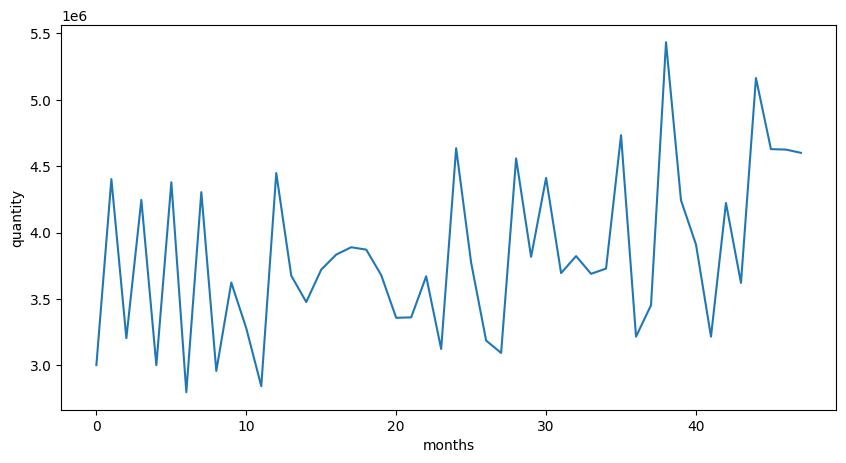

In [9]:

plt.figure(figsize=(10,5))
plt.xlabel('months')
plt.ylabel('quantity')


plt.plot(wsb_df['Sale Quantity'])

*forecasting using moving average*

In [13]:
wsb_df['mv_12'] = wsb_df['Sale Quantity'].rolling(12).mean().shift(1)
wsb_df.head(10)

,Month,Sale Quantity,Promotion Expenses,Competition Promotion,mv_12
0,1,3002666,105,1,NaN
1,2,4401553,145,0,NaN
2,3,3205279,118,1,NaN
3,4,4245349,130,0,NaN
4,5,3001940,98,1,NaN
5,6,4377766,156,0,NaN
6,7,2798343,98,1,NaN
7,8,4303668,144,0,NaN
8,9,2958185,112,1,NaN
9,10,3623386,120,0,NaN


In [14]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
wsb_df[['Sale Quantity', 'mv_12']][36:]

,Sale Quantity,mv_12
36,3216483,3928410.33
37,3453239,3810280.00
38,5431651,3783643.33
39,4241851,3970688.42
40,3909887,4066369.08
41,3216438,4012412.75
42,4222005,3962369.58
43,3621034,3946629.42
44,5162201,3940489.50
45,4627177,4052117.17


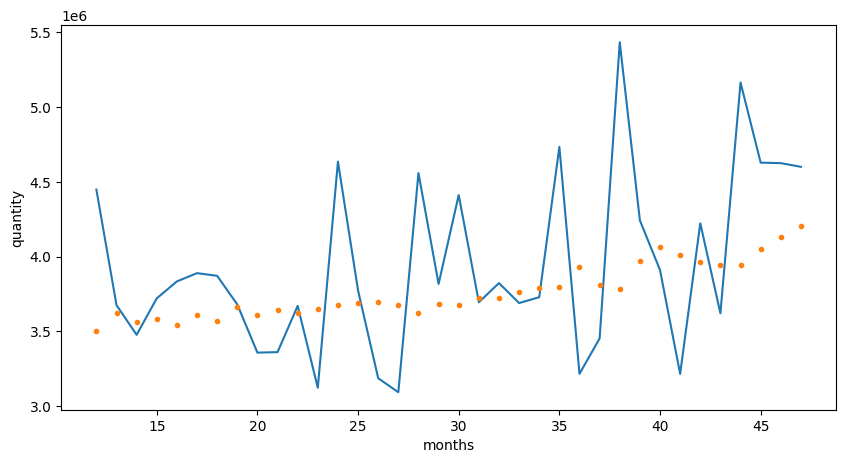

In [18]:
plt.figure(figsize=(10,5))

plt.xlabel('months')
plt.ylabel('quantity')

plt.plot(wsb_df['Sale Quantity'][12:])
plt.plot(wsb_df['mv_12'][12:],'.')

*Forecasting accuracy*

   * MAPE
   * RMSE

*MAPE*

In [19]:
def get_mape(actual, predicted):
   y_true, y_pred = np.array(actual), np.array(predicted)
   return np.round(np.mean(np.abs((actual-predicted)/actual))*100, 2)

In [21]:
get_mape(wsb_df['Sale Quantity'][36:].values, wsb_df['mv_12'][36:].values)

np.float64(14.04)

*RMSE*

In [23]:
np.sqrt(mean_squared_error(wsb_df['Sale Quantity'][36:].values, wsb_df['mv_12'][36:].values))

np.float64(734725.8359239782)

*Exponential smoothing*